# Notebook para extraer las características acústicas de Praat con Parselmouth

Documentación de proyecto original [aquí](https://github.com/drfeinberg/PraatScripts.git):

## This code was modified from the original to carry out the experiments reported in:

**Reyes & García. Identificación de rasgos acústicos para modelado de emociones en maya yucateco: revisión exploratoria. In *IA, modelos, corpus y aplicaciones para la inclusión y revitalización digital de las lenguas indígenas*. UMSNH. In press.**


In [ ]:
pip install praat-parselmouth

In [ ]:
# Libraries
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statistics
import parselmouth
from parselmouth.praat import call
from scipy.stats.mstats import zscore
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [ ]:
# Function to measure source acoustics using default male parameters.

def measurePitch(voiceID, f0min, f0max, unit):
    sound = parselmouth.Sound(voiceID) # read the sound
    duration = call(sound, "Get total duration") # duration
    pitch = call(sound, "To Pitch", 0.0, f0min, f0max) #create a praat pitch object
    meanF0 = call(pitch, "Get mean", 0, 0, unit) # get mean pitch
    stdevF0 = call(pitch, "Get standard deviation", 0 ,0, unit) # get standard deviation
    harmonicity = call(sound, "To Harmonicity (cc)", 0.01, f0min, 0.1, 1.0)
    hnr = call(harmonicity, "Get mean", 0, 0)
    pointProcess = call(sound, "To PointProcess (periodic, cc)", f0min, f0max)
    localJitter = call(pointProcess, "Get jitter (local)", 0, 0, 0.0001, 0.02, 1.3)
    localabsoluteJitter = call(pointProcess, "Get jitter (local, absolute)", 0, 0, 0.0001, 0.02, 1.3)
    rapJitter = call(pointProcess, "Get jitter (rap)", 0, 0, 0.0001, 0.02, 1.3)
    ppq5Jitter = call(pointProcess, "Get jitter (ppq5)", 0, 0, 0.0001, 0.02, 1.3)
    ddpJitter = call(pointProcess, "Get jitter (ddp)", 0, 0, 0.0001, 0.02, 1.3)
    localShimmer =  call([sound, pointProcess], "Get shimmer (local)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    localdbShimmer = call([sound, pointProcess], "Get shimmer (local_dB)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    apq3Shimmer = call([sound, pointProcess], "Get shimmer (apq3)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    aqpq5Shimmer = call([sound, pointProcess], "Get shimmer (apq5)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    apq11Shimmer =  call([sound, pointProcess], "Get shimmer (apq11)", 0, 0, 0.0001, 0.02, 1.3, 1.6)
    ddaShimmer = call([sound, pointProcess], "Get shimmer (dda)", 0, 0, 0.0001, 0.02, 1.3, 1.6)

    return duration, meanF0, stdevF0, hnr, localJitter, localabsoluteJitter, rapJitter, ppq5Jitter, ddpJitter, localShimmer, localdbShimmer, apq3Shimmer, aqpq5Shimmer, apq11Shimmer, ddaShimmer

In [ ]:
# Function measures formants using Formant Position formula
def measureFormants(sound, wave_file, f0min,f0max):
    sound = parselmouth.Sound(sound) # read the sound
    pitch = call(sound, "To Pitch (cc)", 0, f0min, 15, 'no', 0.03, 0.45, 0.01, 0.35, 0.14, f0max)
    pointProcess = call(sound, "To PointProcess (periodic, cc)", f0min, f0max)

    formants = call(sound, "To Formant (burg)", 0.0025, 5, 5000, 0.025, 50)
    numPoints = call(pointProcess, "Get number of points")

    f1_list = []
    f2_list = []
    f3_list = []
    f4_list = []

    # Measure formants only at glottal pulses
    for point in range(0, numPoints):
        point += 1
        t = call(pointProcess, "Get time from index", point)
        f1 = call(formants, "Get value at time", 1, t, 'Hertz', 'Linear')
        f2 = call(formants, "Get value at time", 2, t, 'Hertz', 'Linear')
        f3 = call(formants, "Get value at time", 3, t, 'Hertz', 'Linear')
        f4 = call(formants, "Get value at time", 4, t, 'Hertz', 'Linear')
        f1_list.append(f1)
        f2_list.append(f2)
        f3_list.append(f3)
        f4_list.append(f4)

    f1_list = [f1 for f1 in f1_list if str(f1) != 'nan']
    f2_list = [f2 for f2 in f2_list if str(f2) != 'nan']
    f3_list = [f3 for f3 in f3_list if str(f3) != 'nan']
    f4_list = [f4 for f4 in f4_list if str(f4) != 'nan']

    # calculate mean formants across pulses
    f1_mean = statistics.mean(f1_list)
    f2_mean = statistics.mean(f2_list)
    f3_mean = statistics.mean(f3_list)
    f4_mean = statistics.mean(f4_list)

    # calculate median formants across pulses, this is what is used in all subsequent calcualtions
    # you can use mean if you want, just edit the code in the boxes below to replace median with mean
    f1_median = statistics.median(f1_list)
    f2_median = statistics.median(f2_list)
    f3_median = statistics.median(f3_list)
    f4_median = statistics.median(f4_list)

    return f1_mean, f2_mean, f3_mean, f4_mean, f1_median, f2_median, f3_median, f4_median

In [ ]:
def runPCA(df):
    # z-score the Jitter and Shimmer measurements
    measures = ['localJitter', 'localabsoluteJitter', 'rapJitter', 'ppq5Jitter', 'ddpJitter',
                'localShimmer', 'localdbShimmer', 'apq3Shimmer', 'apq5Shimmer', 'apq11Shimmer', 'ddaShimmer']
    x = df.loc[:, measures].values
    x = StandardScaler().fit_transform(x)
    # PCA
    pca = PCA(n_components=2)
    principalComponents = pca.fit_transform(x)
    principalDf = pd.DataFrame(data = principalComponents, columns = ['JitterPCA', 'ShimmerPCA'])
    principalDf
    return principalDf

In [ ]:
# create lists to save the results
file_list = []
duration_list = []
mean_F0_list = []
sd_F0_list = []
hnr_list = []
localJitter_list = []
localabsoluteJitter_list = []
rapJitter_list = []
ppq5Jitter_list = []
ddpJitter_list = []
localShimmer_list = []
localdbShimmer_list = []
apq3Shimmer_list = []
aqpq5Shimmer_list = []
apq11Shimmer_list = []
ddaShimmer_list = []
f1_mean_list = []
f2_mean_list = []
f3_mean_list = []
f4_mean_list = []
f1_median_list = []
f2_median_list = []
f3_median_list = []
f4_median_list = []

# Go through all the wave files in the folder and measure all the acoustics
for wave_file in glob.glob('*.wav'): # Changed from "audio/*.wav" to "*.wav"
    sound = parselmouth.Sound(wave_file)
    (duration, meanF0, stdevF0, hnr, localJitter, localabsoluteJitter, rapJitter, ppq5Jitter, ddpJitter,
     localShimmer, localdbShimmer, apq3Shimmer, aqpq5Shimmer, apq11Shimmer, ddaShimmer) = measurePitch(
        sound, 75, 300, "Hertz")
    (f1_mean, f2_mean, f3_mean, f4_mean, f1_median, f2_median, f3_median, f4_median) = measureFormants(
        sound, wave_file, 75, 300)
    file_list.append(wave_file) # make an ID list
    duration_list.append(duration) # make duration list
    mean_F0_list.append(meanF0) # make a mean F0 list
    sd_F0_list.append(stdevF0) # make a sd F0 list
    hnr_list.append(hnr) #add HNR data

    # add raw jitter and shimmer measures
    localJitter_list.append(localJitter)
    localabsoluteJitter_list.append(localabsoluteJitter)
    rapJitter_list.append(rapJitter)
    ppq5Jitter_list.append(ppq5Jitter)
    ddpJitter_list.append(ddpJitter)
    localShimmer_list.append(localShimmer)
    localdbShimmer_list.append(localdbShimmer)
    apq3Shimmer_list.append(apq3Shimmer)
    aqpq5Shimmer_list.append(aqpq5Shimmer)
    apq11Shimmer_list.append(apq11Shimmer)
    ddaShimmer_list.append(ddaShimmer)

    # add the formant data
    f1_mean_list.append(f1_mean)
    f2_mean_list.append(f2_mean)
    f3_mean_list.append(f3_mean)
    f4_mean_list.append(f4_mean)
    f1_median_list.append(f1_median)
    f2_median_list.append(f2_median)
    f3_median_list.append(f3_median)
    f4_median_list.append(f4_median)

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Add the data to Pandas
df = pd.DataFrame(np.column_stack([file_list, duration_list, mean_F0_list, sd_F0_list, hnr_list,
                                   localJitter_list, localabsoluteJitter_list, rapJitter_list,
                                   ppq5Jitter_list, ddpJitter_list, localShimmer_list,
                                   localdbShimmer_list, apq3Shimmer_list, aqpq5Shimmer_list,
                                   apq11Shimmer_list, ddaShimmer_list, f1_mean_list,
                                   f2_mean_list, f3_mean_list, f4_mean_list,
                                   f1_median_list, f2_median_list, f3_median_list,
                                   f4_median_list]),
                                   columns=['Emotion', 'duration', 'meanF0Hz', 'stdevF0Hz', 'HNR',
                                            'localJitter', 'localabsoluteJitter', 'rapJitter',
                                            'ppq5Jitter', 'ddpJitter', 'localShimmer',
                                            'localdbShimmer', 'apq3Shimmer', 'apq5Shimmer',
                                            'apq11Shimmer', 'ddaShimmer', 'f1_mean', 'f2_mean',
                                            'f3_mean', 'f4_mean', 'f1_median',
                                            'f2_median', 'f3_median', 'f4_median'])

if not df.empty:
    pcaData = runPCA(df) # Run jitter and shimmer PCA
    df = pd.concat([df, pcaData], axis=1) # Add PCA data
else:
    print("Warning: DataFrame is empty. Cannot perform PCA or further analysis.")
    # Create an empty pcaData DataFrame with the expected columns to avoid errors later
    pcaData = pd.DataFrame(columns=['JitterPCA', 'ShimmerPCA'])
    df = pd.concat([df, pcaData], axis=1) # Concatenate empty dataframes

# reload the data so it's all numbers
df.to_csv("processed_results.csv", index=False)
df = pd.read_csv('processed_results.csv', header=0)
df.sort_values('Emotion').head(20)

,Emotion,duration,meanF0Hz,stdevF0Hz,HNR,localJitter,localabsoluteJitter,rapJitter,ppq5Jitter,ddpJitter,...,f1_mean,f2_mean,f3_mean,f4_mean,f1_median,f2_median,f3_median,f4_median,JitterPCA,ShimmerPCA
11,Alegría1.wav,2.481633,161.269331,37.727559,15.826934,0.020576,0.000128,0.007071,0.010798,0.021213,...,416.283607,1704.441380,2580.605410,3602.420316,299.462364,1643.036130,2681.189391,3704.331304,-2.564803,-0.182351
6,Alegría2.wav,5.120000,154.051934,36.538257,12.128283,0.029737,0.000194,0.010269,0.012455,0.030808,...,493.377584,1564.076737,2664.617736,3683.267816,341.190647,1594.223468,2715.071944,3800.473392,0.410969,1.542315
0,Enfado1.wav,3.317551,134.406952,35.084886,9.686554,0.031444,0.000234,0.012996,0.016650,0.038989,...,431.059171,1816.665505,2675.340416,3585.227697,294.604734,1684.147116,2594.254019,3592.624106,5.686191,-0.199265
7,Enfado2.wav,2.351020,184.417684,49.113592,11.035412,0.027416,0.000150,0.010237,0.012387,0.030710,...,437.404226,1795.811922,2573.070327,3599.515421,427.378905,1730.417082,2559.937676,3774.147747,1.010571,-0.021060
4,Ira1.wav,2.455510,169.414030,38.781643,14.023234,0.015066,0.000089,0.005614,0.006891,0.016841,...,473.619058,1715.545231,2638.461767,3623.330913,392.178316,1598.639805,2608.327637,3641.225189,-4.078541,-1.950783
5,Ira2.wav,4.493061,181.920782,52.131032,13.401406,0.021391,0.000118,0.007516,0.009072,0.022547,...,456.057828,1763.871150,2520.034425,3458.839431,350.709138,1686.459923,2564.530737,3466.826427,-1.559096,-1.274653
10,Miedo1.wav,2.899592,109.433425,18.742368,13.116391,0.025774,0.000236,0.011891,0.015133,0.035673,...,670.806799,1992.784720,2979.980157,3753.129477,305.336507,1949.614676,2945.547709,3701.413815,4.744752,-0.890942
8,Miedo2.wav,4.466939,145.128692,20.270206,12.428442,0.026259,0.000181,0.009914,0.012464,0.029741,...,477.719316,1766.249503,2741.940843,3739.347519,298.700688,1744.497798,2753.469238,3753.618281,0.604334,0.653177
9,Sorpresa1.wav,2.560000,136.821399,43.664131,14.356741,0.023088,0.000169,0.007881,0.009091,0.023644,...,414.188136,1819.789994,2690.515820,3657.514146,228.086863,1758.600044,2655.176995,3741.417534,-0.299735,-1.338314
3,Sorpresa2.wav,5.067755,152.707018,40.340982,10.476707,0.029962,0.000196,0.009643,0.012638,0.028929,...,517.492872,1602.602636,2617.982760,3583.441881,362.198460,1604.740594,2676.720989,3661.986029,1.354784,0.544663


In [ ]:
df['pF'] = (zscore(df.f1_median) + zscore(df.f2_median) + zscore(df.f3_median) + zscore(df.f4_median)) / 4


In [ ]:
df['fdisp'] = (df['f4_median'] - df['f1_median']) / 3

In [ ]:
df['avgFormant'] = (df['f1_median'] + df['f2_median'] + df['f3_median'] + df['f4_median']) / 4

In [ ]:
df['mff'] = (df['f1_median'] * df['f2_median'] * df['f3_median'] * df['f4_median']) ** 0.25

In [ ]:
# reload the data again
df.to_csv("processed_results.csv", index=False)
df = pd.read_csv('processed_results.csv', header=0)

df['fitch_vtl'] = ((1 * (35000 / (4 * df['f1_median']))) +
                   (3 * (35000 / (4 * df['f2_median']))) +
                   (5 * (35000 / (4 * df['f3_median']))) +
                   (7 * (35000 / (4 * df['f4_median'])))) / 4

In [ ]:
xysum = (0.5 * df['f1_median']) + (1.5 * df['f2_median']) + (2.5 * df['f3_median']) + (3.5 * df['f4_median'])
xsquaredsum = (0.5 ** 2) + (1.5 ** 2) + (2.5 ** 2) + (3.5 ** 2)
df['delta_f'] = xysum / xsquaredsum

In [ ]:
df['vtl_delta_f'] = 35000 / (2 * df['delta_f'])

In [ ]:
# Write out the final dataframe
df.to_csv("processed_results2.csv", index=False)

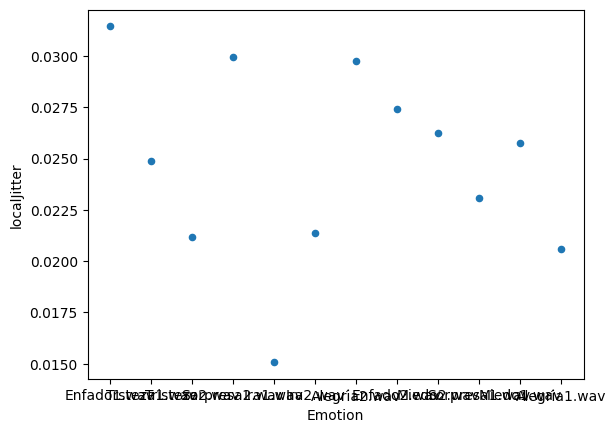

In [ ]:
graph = pd.read_csv('processed_results2.csv', header=0).plot(kind='scatter', x='Emotion', y='localJitter')

/tmp/ipykernel_7191/3493194871.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  kind='scatter', x='Emotion', y='localJitter', title = 'Jitter').set_xticklabels(labels, rotation=90)


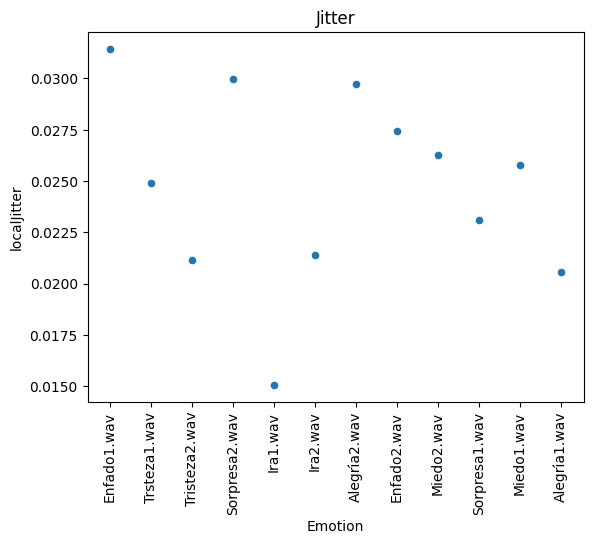

In [ ]:
labels = pd.read_csv('processed_results2.csv', header=0)['Emotion'].tolist()
graph = pd.read_csv('processed_results2.csv', header=0).plot(
    kind='scatter', x='Emotion', y='localJitter', title = 'Jitter').set_xticklabels(labels, rotation=90)

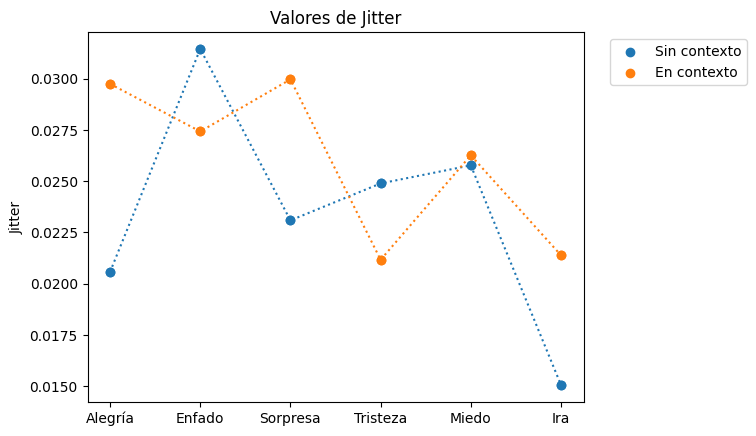

In [ ]:
import matplotlib.pyplot as plt

#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([0.02058, 0.03144, 0.02309, 0.02489, 0.02577, 0.01507])
y_data2 = np.array([0.02974, 0.02742, 0.02996, 0.02117, 0.02626, 0.02139])

plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de Jitter')
plt.ylabel('Jitter')
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("Jitter.png", bbox_inches='tight')
plt.show()



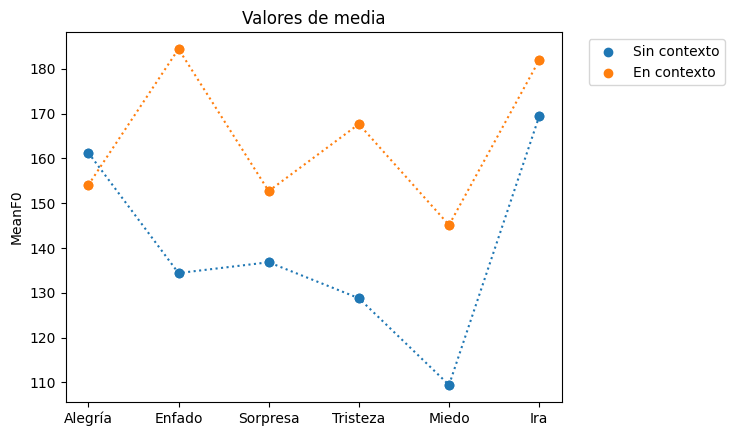

In [ ]:
#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([161.26933,134.40695,136.8214,128.79456,109.43342,169.41403])
y_data2 = np.array([154.05193,184.41768,152.70702,167.65655,145.12869,181.92078])
#y_data3 = np.array([37.72756,35.08489,43.66413,23.49107,18.74237,38.78164])
#y_data4 = np.array([36.53826,49.11359,40.34098,30.82042,20.27021,52.13103])


plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.scatter(x, y_data3, label='StaDev sin contexto')
#plt.scatter(x, y_data4, label='StaDev en contexto')
#plt.xticks(rotation=90)
plt.title('Valores de media')
plt.ylabel('MeanF0')
#plt.grid(True)
plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')

plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.savefig("MeanF0.png", bbox_inches='tight')
plt.show()

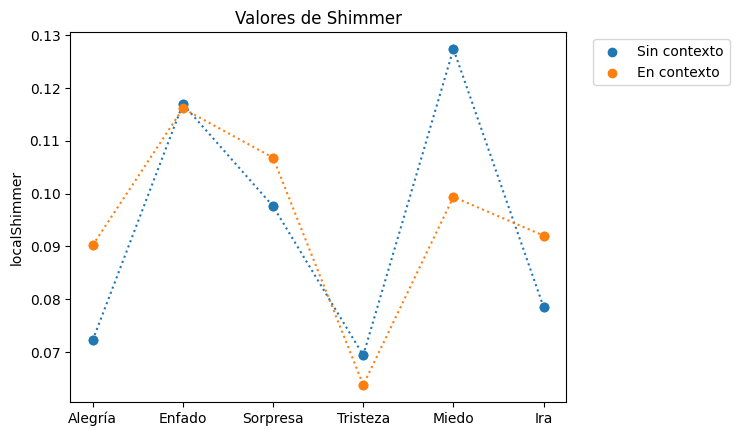

In [ ]:
#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([0.07225,0.11694,0.0976,0.0694,0.12736,0.07852    ])
y_data2 = np.array([0.09023,0.1161,0.1068,0.06378,0.09937,0.09204])

plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de Shimmer')
plt.ylabel('localShimmer')
#plt.rcParams["figure.figsize"] = (12, 6)
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("Shimmer.png", bbox_inches='tight')
plt.show()

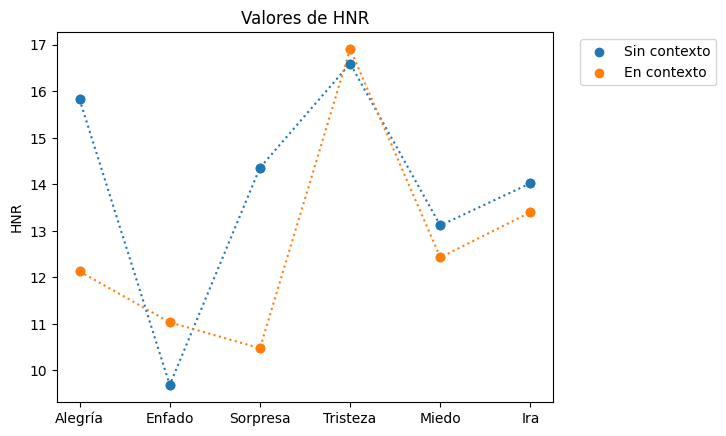

In [ ]:
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([15.82693354,9.686554033,14.35674114,16.59744788,13.11639061,14.02323429])
y_data2 = np.array([12.12828338,11.03541164,10.47670673,16.91088715,12.42844152,13.40140565])

plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de HNR')
plt.ylabel('HNR')
#plt.rcParams["figure.figsize"] = (12, 6)
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("HNR.png", bbox_inches='tight')
plt.show()

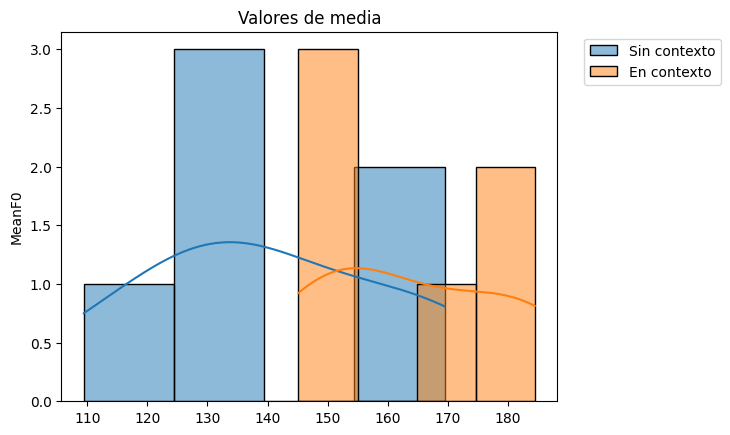

In [ ]:
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([161.26933,134.40695,136.8214,128.79456,109.43342,169.41403])
y_data2 = np.array([154.05193,184.41768,152.70702,167.65655,145.12869,181.92078])

plt.figure() # New figure for the plot
sns.histplot(y_data1, label='Sin contexto', kde=True)
sns.histplot(y_data2, label='En contexto', kde=True)
#plt.scatter(x, y_data3, label='StaDev sin contexto')
#plt.scatter(x, y_data4, label='StaDev en contexto')
#plt.xticks(rotation=90)
plt.title('Valores de media')
plt.ylabel('MeanF0')
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
#plt.savefig("MeanF0.png")
plt.show()

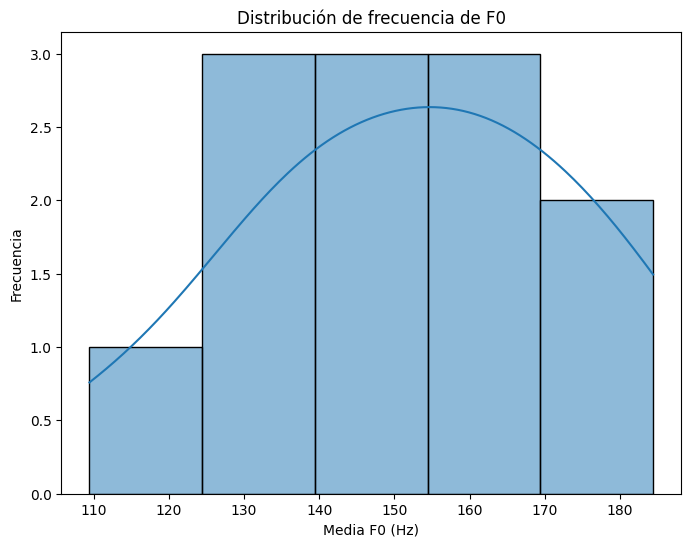

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.histplot(df['meanF0Hz'], kde=True)
plt.title('Distribución de frecuencia de F0')
plt.xlabel('Media F0 (Hz)')
plt.ylabel('Frecuencia')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("DistributionF0.png")
plt.show()

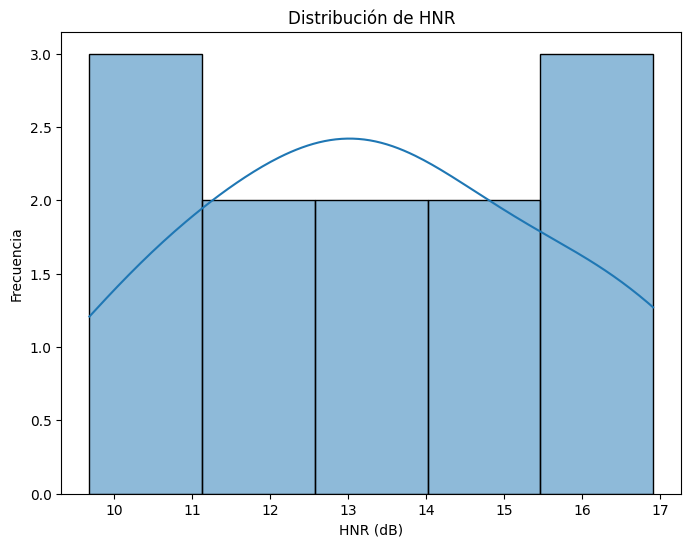

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['HNR'], kde=True)
plt.title('Distribución de HNR')
plt.xlabel('HNR (dB)')
plt.ylabel('Frecuencia')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("DistribucionHNR.png")
plt.show()

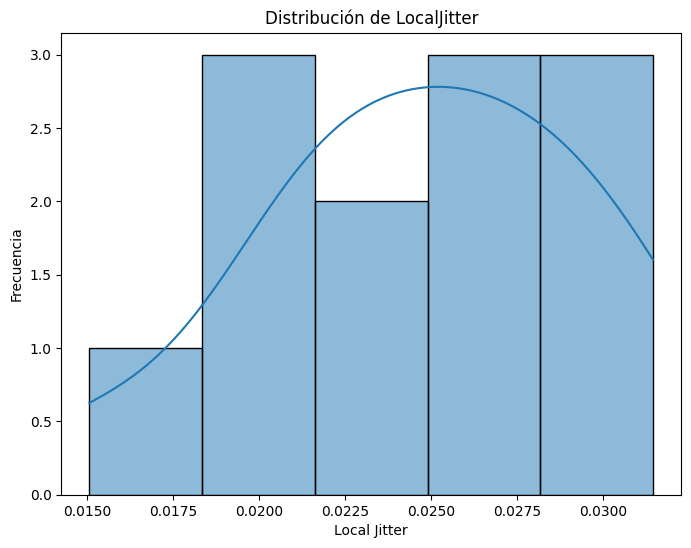

In [ ]:
plt.figure(figsize=(8, 6))
sns.histplot(df['localJitter'], kde=True)
plt.title('Distribución de LocalJitter')
plt.xlabel('Local Jitter')
plt.ylabel('Frecuencia')
#plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig("DistribucionJitter.png")
plt.show()

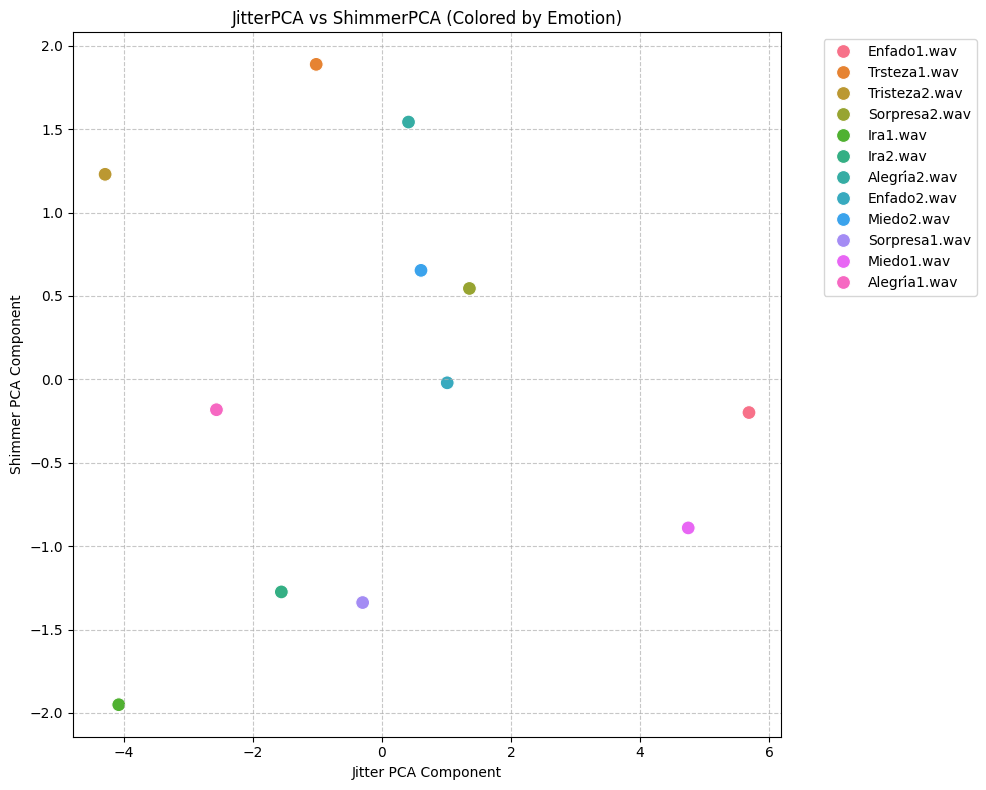

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df['JitterPCA'], y=df['ShimmerPCA'], hue=df['Emotion'], s=100)
plt.title('JitterPCA vs ShimmerPCA (Colored by Emotion)')
plt.xlabel('Jitter PCA Component')
plt.ylabel('Shimmer PCA Component')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

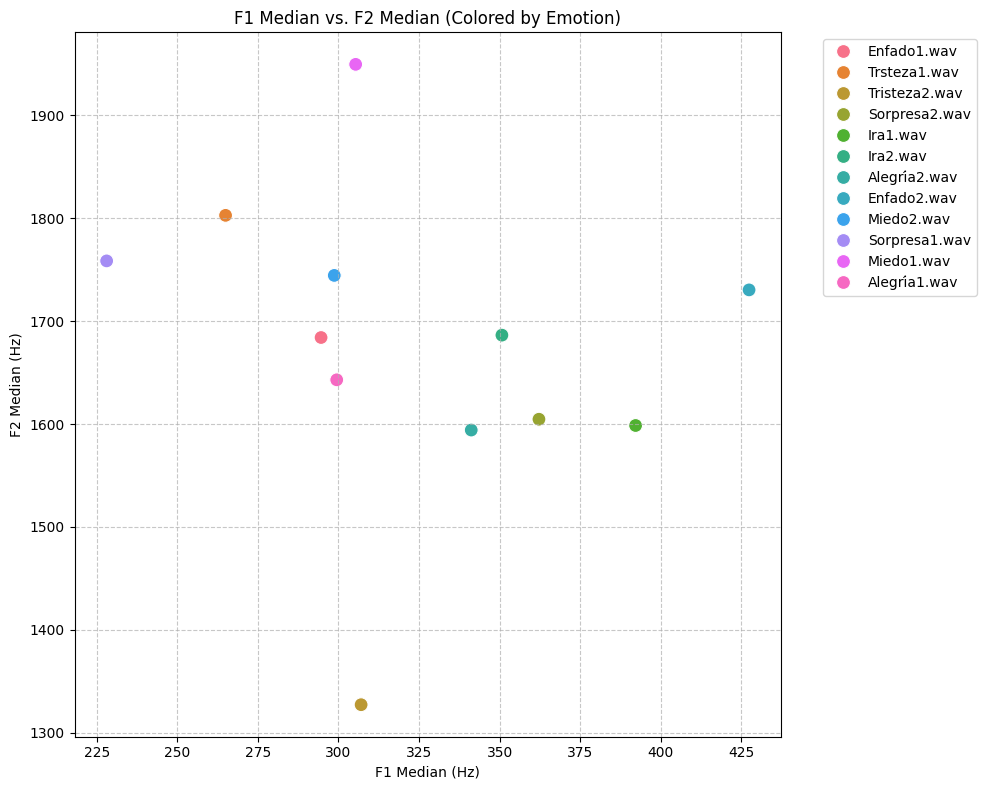

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df['f1_median'], y=df['f2_median'], hue=df['Emotion'], s=100)
plt.title('F1 Median vs. F2 Median (Colored by Emotion)')
plt.xlabel('F1 Median (Hz)')
plt.ylabel('F2 Median (Hz)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

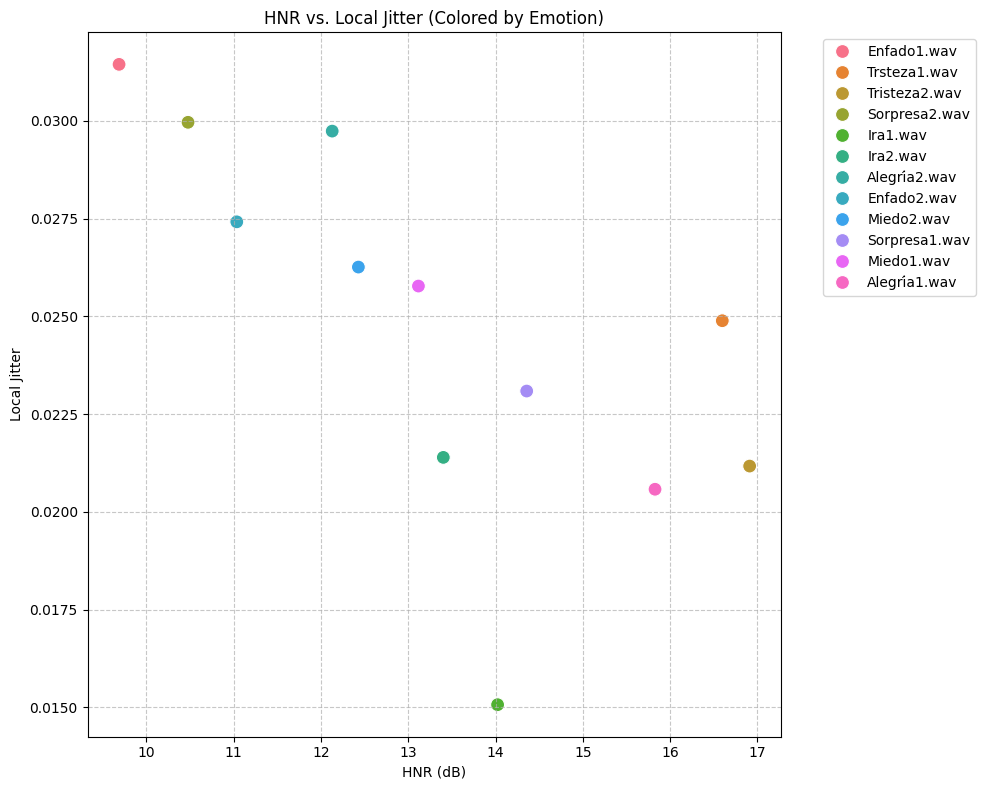

In [ ]:
plt.figure(figsize=(10, 8))
sns.scatterplot(x=df['HNR'], y=df['localJitter'], hue=df['Emotion'], s=100)
plt.title('HNR vs. Local Jitter (Colored by Emotion)')
plt.xlabel('HNR (dB)')
plt.ylabel('Local Jitter')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

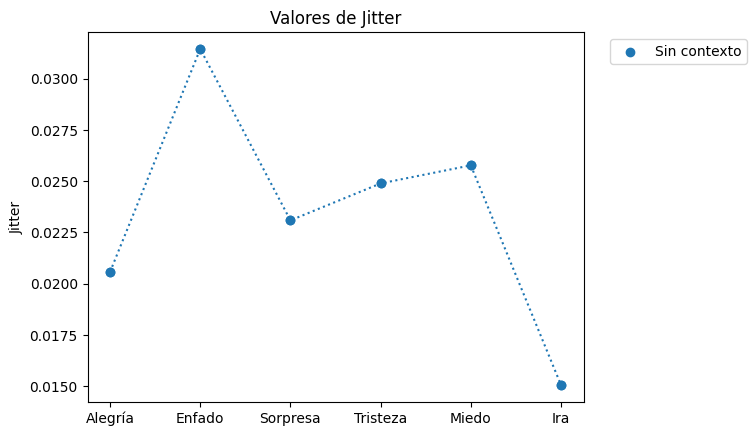

In [ ]:
import matplotlib.pyplot as plt

#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([0.02058, 0.03144, 0.02309, 0.02489, 0.02577, 0.01507])
#y_data2 = np.array([0.02974, 0.02742, 0.02996, 0.02117, 0.02626, 0.02139])

plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
#plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de Jitter')
plt.ylabel('Jitter')
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.plot(x, y_data1, marker='o', linestyle='dotted')
#plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("Jitter-sincontexto.png", bbox_inches='tight')
plt.show()

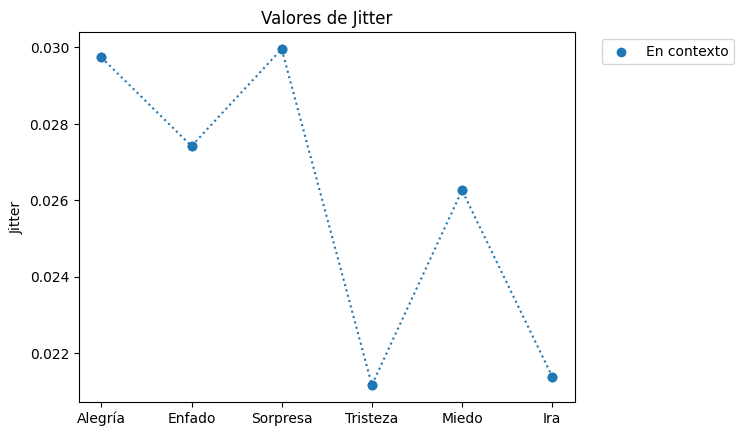

In [ ]:
import matplotlib.pyplot as plt

#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
#y_data1 = np.array([0.02058, 0.03144, 0.02309, 0.02489, 0.02577, 0.01507])
y_data2 = np.array([0.02974, 0.02742, 0.02996, 0.02117, 0.02626, 0.02139])

plt.figure() # New figure for the plot
#plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de Jitter')
plt.ylabel('Jitter')
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
#plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("Jitter-encontexto.png", bbox_inches='tight')
plt.show()

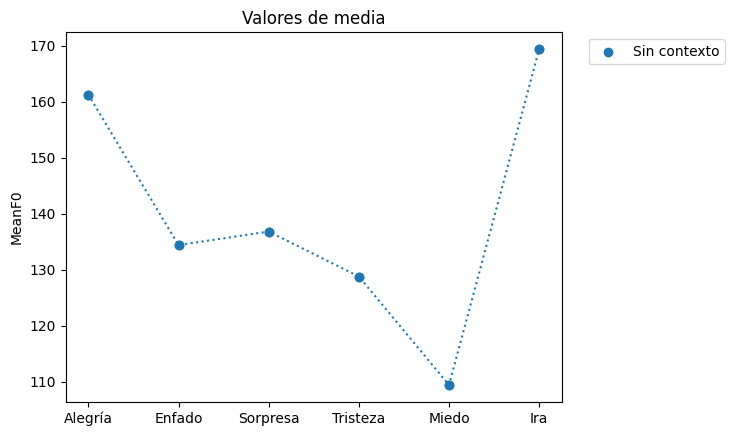

In [ ]:
#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([161.26933,134.40695,136.8214,128.79456,109.43342,169.41403])
#y_data2 = np.array([154.05193,184.41768,152.70702,167.65655,145.12869,181.92078])
#y_data3 = np.array([37.72756,35.08489,43.66413,23.49107,18.74237,38.78164])
#y_data4 = np.array([36.53826,49.11359,40.34098,30.82042,20.27021,52.13103])


plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
#plt.scatter(x, y_data2, label='En contexto')
#plt.scatter(x, y_data3, label='StaDev sin contexto')
#plt.scatter(x, y_data4, label='StaDev en contexto')
#plt.xticks(rotation=90)
plt.title('Valores de media')
plt.ylabel('MeanF0')
#plt.grid(True)
plt.plot(x, y_data1, marker='o', linestyle='dotted')
#plt.plot(x, y_data2, marker='o', linestyle='dotted')

plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.savefig("MeanF0-sincontexto.png", bbox_inches='tight')
plt.show()

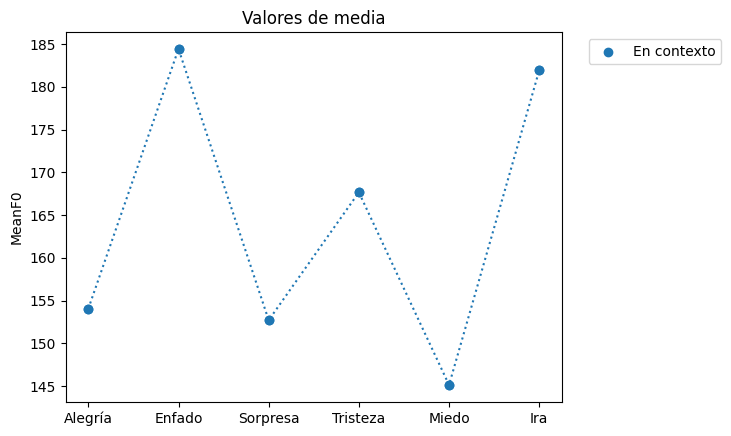

In [ ]:
#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
#y_data1 = np.array([161.26933,134.40695,136.8214,128.79456,109.43342,169.41403])
y_data2 = np.array([154.05193,184.41768,152.70702,167.65655,145.12869,181.92078])
#y_data3 = np.array([37.72756,35.08489,43.66413,23.49107,18.74237,38.78164])
#y_data4 = np.array([36.53826,49.11359,40.34098,30.82042,20.27021,52.13103])


plt.figure() # New figure for the plot
#plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.scatter(x, y_data3, label='StaDev sin contexto')
#plt.scatter(x, y_data4, label='StaDev en contexto')
#plt.xticks(rotation=90)
plt.title('Valores de media')
plt.ylabel('MeanF0')
#plt.grid(True)
#plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')

plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.savefig("MeanF0-encontexto.png", bbox_inches='tight')
plt.show()

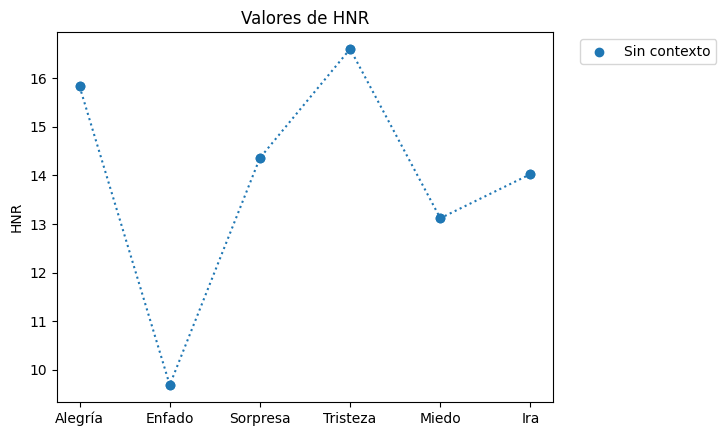

In [ ]:
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([15.82693354,9.686554033,14.35674114,16.59744788,13.11639061,14.02323429])
#y_data2 = np.array([12.12828338,11.03541164,10.47670673,16.91088715,12.42844152,13.40140565])

plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Sin contexto')
#plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de HNR')
plt.ylabel('HNR')
#plt.rcParams["figure.figsize"] = (12, 6)
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.plot(x, y_data1, marker='o', linestyle='dotted')
#plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("HNR-sincontexto.png", bbox_inches='tight')
plt.show()

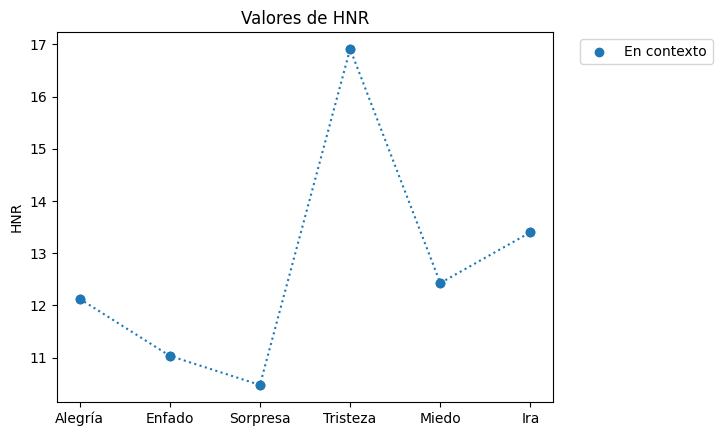

In [ ]:
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
#y_data1 = np.array([15.82693354,9.686554033,14.35674114,16.59744788,13.11639061,14.02323429])
y_data2 = np.array([12.12828338,11.03541164,10.47670673,16.91088715,12.42844152,13.40140565])

plt.figure() # New figure for the plot
#plt.scatter(x, y_data1, label='Sin contexto')
plt.scatter(x, y_data2, label='En contexto')
#plt.xticks(rotation=90)
plt.title('Valores de HNR')
plt.ylabel('HNR')
#plt.rcParams["figure.figsize"] = (12, 6)
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
#plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.savefig("HNR-encontexto.png", bbox_inches='tight')
plt.show()

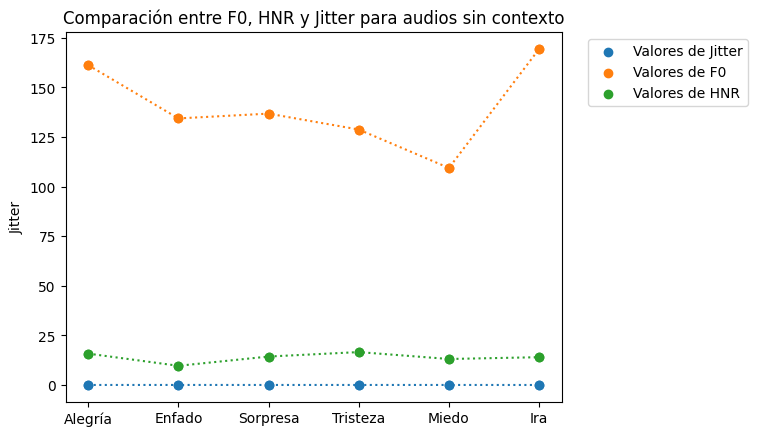

In [ ]:
import matplotlib.pyplot as plt

#Values are stored in valuesParselmouth.csv (come from processed_results2.csv)
x = np.array(['Alegría', 'Enfado', 'Sorpresa', 'Tristeza', 'Miedo', 'Ira'])
y_data1 = np.array([0.02058, 0.03144, 0.02309, 0.02489, 0.02577, 0.01507])
y_data2 = np.array([161.26933,134.40695,136.8214,128.79456,109.43342,169.41403])
y_data3 = np.array([15.82693354,9.686554033,14.35674114,16.59744788,13.11639061,14.02323429])

plt.figure() # New figure for the plot
plt.scatter(x, y_data1, label='Valores de Jitter')
plt.scatter(x, y_data2, label='Valores de F0')
plt.scatter(x, y_data3, label='Valores de HNR')
#plt.xticks(rotation=90)
plt.title('Comparación entre F0, HNR y Jitter para audios sin contexto')
plt.ylabel('Jitter')
plt.legend(bbox_to_anchor=(1.04, 1), loc='upper left')
plt.plot(x, y_data1, marker='o', linestyle='dotted')
plt.plot(x, y_data2, marker='o', linestyle='dotted')
plt.plot(x, y_data3, marker='o', linestyle='dotted')
plt.savefig("F0-HNR-Jitter.png", bbox_inches='tight')
plt.show()